In [ ]:
!nvidia-smi

Thu Dec  5 21:36:47 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   57C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
PyTorch version 2.5.1+cu121
Torchvision version 0.20.1+cu121
Numpy version 1.26.4
Pandas version 2.2.2


Set up Dataset and Dataloader

In [ ]:
class GalaxyImageDataset (Dataset) :
  def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

  def __len__(self):
        return len(self.data)

  def __getitem__(self, idx):
        return self.data[idx]

  @property
  def classes(self):
        return self.data.classes


In [ ]:
# upload the datset into my google drive
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# unzip the dataset zip file
!unzip -q '/content/drive/MyDrive/galaxy_zip/images_E_S_SB_227x227_a_03 (1).zip' -d '/content/dataset'

replace /content/dataset/images_E_S_SB_227x227_a_03_test/E/100022.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_train'
dataset = GalaxyImageDataset(data_dir = data_dir);

In [ ]:
len(dataset)

120432

0


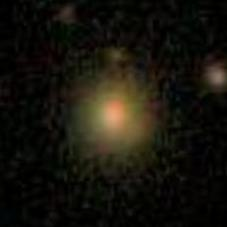

In [ ]:
image, label = dataset[0]
print(label)
image

In [ ]:
data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_train'
# maps each label(number) to the corresponding galaxy "classification"
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'E', 1: 'S', 2: 'SB'}


In [ ]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])

data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_train'
dataset = GalaxyImageDataset(data_dir = data_dir, transform=transform)

In [ ]:
image, label = dataset[100]
# every image has been transformed into a tensor(3 represents RGB, 227x227 represents size)
image.shape

torch.Size([3, 227, 227])

In [ ]:
for image, label in dataset:
    break

label

0

In [ ]:
# load in our dataset
dataloader = DataLoader(dataset, batch_size = 32, shuffle = True)

In [ ]:
#iterate over dataloader
for images, labels in dataloader:
    break

images.shape, labels.shape


(torch.Size([32, 3, 227, 227]), torch.Size([32]))

In [ ]:
# labels are also shuffled
labels

tensor([0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 2, 1, 0, 1, 1, 2, 0, 0, 0, 2, 1,
        2, 0, 0, 1, 1, 0, 1, 1])

In [ ]:
'''class GalaxyImageClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(GalaxyImageClassifier, self).__init__()
        # Where we define all the parts of the model
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        # removing the last layer of the model
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        enet_out_size = 1280
        # Make a classifier
        self.classifier = nn.Linear(enet_out_size, num_classes)


    def forward(self, x):
        # Connect these parts and return the output
        x = self.features(x)
       # x = x.view(x.size(0), -1)
        output = self.classifier(x)
        return output


In [ ]:
class GalaxyImageClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(GalaxyImageClassifier, self).__init__()
        # Load EfficientNet as the feature extractor
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])  # Remove the last layer

        enet_out_size = 1280  # Feature vector size from EfficientNet

        # Add additional fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(enet_out_size, 512),  # First FC layer
            nn.ReLU(),
            nn.Dropout(0.5),               # Regularization
            nn.Linear(512, 128),           # Second FC layer
            nn.ReLU(),
            nn.Dropout(0.5),               # Regularization
            nn.Linear(128, num_classes)    # Output layer
        )

    def forward(self, x):
        # Pass through EfficientNet's feature extractor
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten feature map
        # Pass through the classifier
        output = self.classifier(x)
        return output


In [ ]:
model = GalaxyImageClassifier(num_classes = 3)
print(str(model) [:500])

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


GalaxyImageClassifier(
  (base_model): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=F


In [ ]:
# check if model takes in input properly
example_output = model(images)
print(example_output)
example_output.shape # [batch_size, num_classes]

NameError: name 'images' is not defined

In [ ]:
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])


train_data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_train'
test_data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_test'

train_dataset = GalaxyImageDataset(data_dir = train_data_dir, transform = transform)
val_dataset = GalaxyImageDataset(data_dir = train_data_dir, transform = transform)
test_dataset = GalaxyImageDataset(data_dir = test_data_dir, transform=transform)

# dataset is split into 90% training and 10% test
# will split training dataset(called dataset) into 90% training and 10% validation
# thus final split will be: 81% training, 9% validation, 10% test
dataset_size = len(train_dataset)
indices = list(range(dataset_size))
#extract our labels
labels = [train_dataset[i][1] for i in range(len(train_dataset))]


train_indices, val_indices = train_test_split(indices, test_size=0.1, stratify = labels, random_state=42)

# create subsets for training and validation
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

#print lengths of each subset
print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")
print(f"Test set size: {len(test_dataset)}")


# load in our training, validation, and test data
train_loader = DataLoader(train_subset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_subset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)


Training set size: 108388
Validation set size: 12044
Test set size: 13380


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset
import numpy as np

class BalancedGalaxyDataset(Dataset):
    def __init__(self, data_dir, transform=None, num_images_per_category=8000):
        super().__init__()
        self.transform = transform
        self.data = []
        self.targets = []

        # Load the data using ImageFolder
        full_dataset = ImageFolder(data_dir)

        # Separate data by category
        class_indices = {class_idx: [] for class_idx in range(len(full_dataset.classes))}
        for idx, (_, label) in enumerate(full_dataset):
            class_indices[label].append(idx)

        # Sample up to the specified number of images per category
        for class_idx, indices in class_indices.items():
            sampled_indices = np.random.choice(
                indices, size=min(len(indices), num_images_per_category), replace=False
            )
            for idx in sampled_indices:
                self.data.append(full_dataset.samples[idx][0])  # File path
                self.targets.append(class_idx)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.targets[idx]

        # Load the image
        from PIL import Image
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [ ]:
# Transform for resizing and tensor conversion
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])

# Specify data directories
train_data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_train'
test_data_dir = '/content/dataset/images_E_S_SB_227x227_a_03_test'

# Use the Balanced Dataset
train_dataset = BalancedGalaxyDataset(data_dir=train_data_dir, transform=transform, num_images_per_category=8000)
test_dataset = ImageFolder(test_data_dir, transform=transform)

# Split training dataset into training and validation subsets
from sklearn.model_selection import train_test_split

dataset_size = len(train_dataset)
indices = list(range(dataset_size))
labels = train_dataset.targets  # Labels already available in the custom dataset

train_indices, val_indices = train_test_split(indices, test_size=0.1, stratify=labels, random_state=42)

# Create subsets
train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

# Print sizes
print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")
print(f"Test set size: {len(test_dataset)}")

# Load data
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Training set size: 21600
Validation set size: 2400
Test set size: 13380


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
num_epochs = 10  # Increase the number of epochs
train_losses = []
val_losses = []

model = GalaxyImageClassifier(num_classes=3)
model.to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0001)  # Reduced learning rate and weight decay

# Optionally, use a learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(num_epochs):
    # Set the model to train mode
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc="Training loop"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)

    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    # Print epoch stats
    print(f"Epoch {epoch + 1}/{num_epochs} - Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

    # Step the scheduler
    scheduler.step()


Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.7504, Validation Loss: 0.6255


Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

...

Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 5/10 - Train Loss: 0.4758, Validation Loss: 0.6143


Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# an epoch is one run through the entire dataset
num_epochs = 10
train_losses = []
val_losses = []

model = GalaxyImageClassifier(num_classes = 3)
model.to(device)

#define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay=0.00001)


for epoch in range(num_epochs):
  # set the model to train
  model.train()
  running_loss = 0.0
  # tqdm allows us to see a progress bar
  for images, labels in tqdm(train_loader, desc = "Training loop"):
    # move the inputs and outputs to the device
    images, labels = images.to(device), labels.to(device)
    # zero the parameter gradients
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    # Computes the gradients of the loss with respect to the model parameters through backpropagation. This prepares the model for a parameter update in the next step.
    loss.backward()
    # updates models parameters based on computed gradients, where model actually "learns" to reduce loss
    optimizer.step()
    running_loss += loss.item() * labels.size(0)
  # calculates the average loss for the current epoch
  train_loss = running_loss / len(train_loader.dataset)
  train_losses.append(train_loss)

  # validation phase
  model.eval()
  running_loss = 0.0
  with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validation loop'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
  val_loss = running_loss / len(val_loader.dataset)
  val_losses.append(val_loss)

  print(f"Epoch {epoch + 1}/{num_epochs} - Train Loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}")

Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.7078, Validation loss: 0.6115


Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.2455, Validation loss: 0.8662


Training loop:   0%|          | 0/675 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.1931, Validation loss: 0.8508


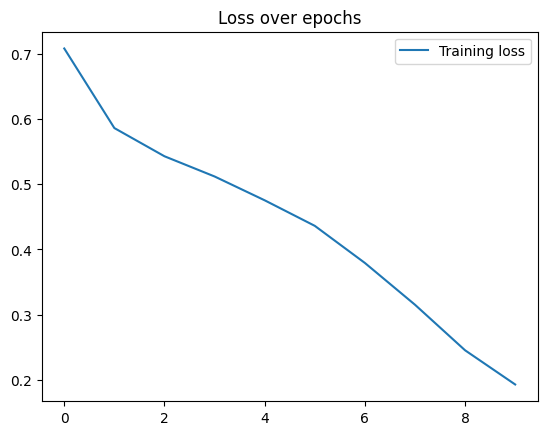

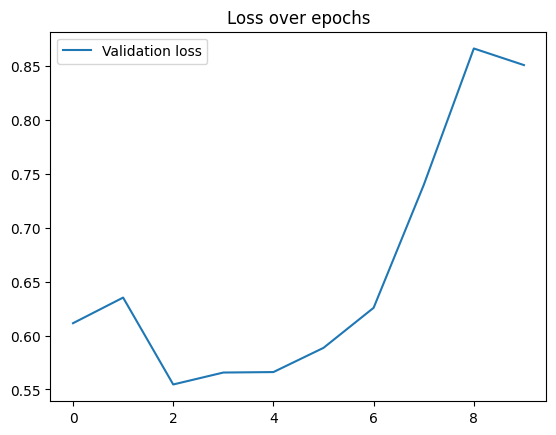

In [ ]:
# visualize data
plt.plot(train_losses, label='Training loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

In [ ]:
# evaluate our results using a prediction function
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# Load and preprocess the image
def preprocess_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return image, transform(image).unsqueeze(0)

def extract_label_from_path(image_path):
    # Extract the parent folder name as the label
    label_name = os.path.basename(os.path.dirname(image_path))
    return label_name

# Predict using the model
def predict(model, image_tensor, device):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        outputs = model(image_tensor)
        # converts the raw data from our model(logits) into a probability distribution across classes
        # uses sotftmax function
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        # converts probabilities tensor into a numpy array
    return probabilities.cpu().numpy().flatten()

# display results
def visualize_predictions(original_image, probabilities, class_names, true_label = None):
    fig, axarr = plt.subplots(1, 2, figsize=(14, 7))

    # Display image
    axarr[0].imshow(original_image)
    axarr[0].axis("off")
    # Add the true label to the image title
    if true_label is not None:
      axarr[0].set_title(f"True Label: {true_label}", fontsize=14)
    # Display predictions
    axarr[1].barh(class_names, probabilities)
    axarr[1].set_xlabel("Probability")
    axarr[1].set_title("Class Predictions")
    axarr[1].set_xlim(0, 1)

    plt.tight_layout()
    plt.show()

In [ ]:
# to do:
# ensure that I split the datasets proportionally to have an equal amount of each class(E, S,SB)  *
# figure out how to show the actual label/class along with prediction

E


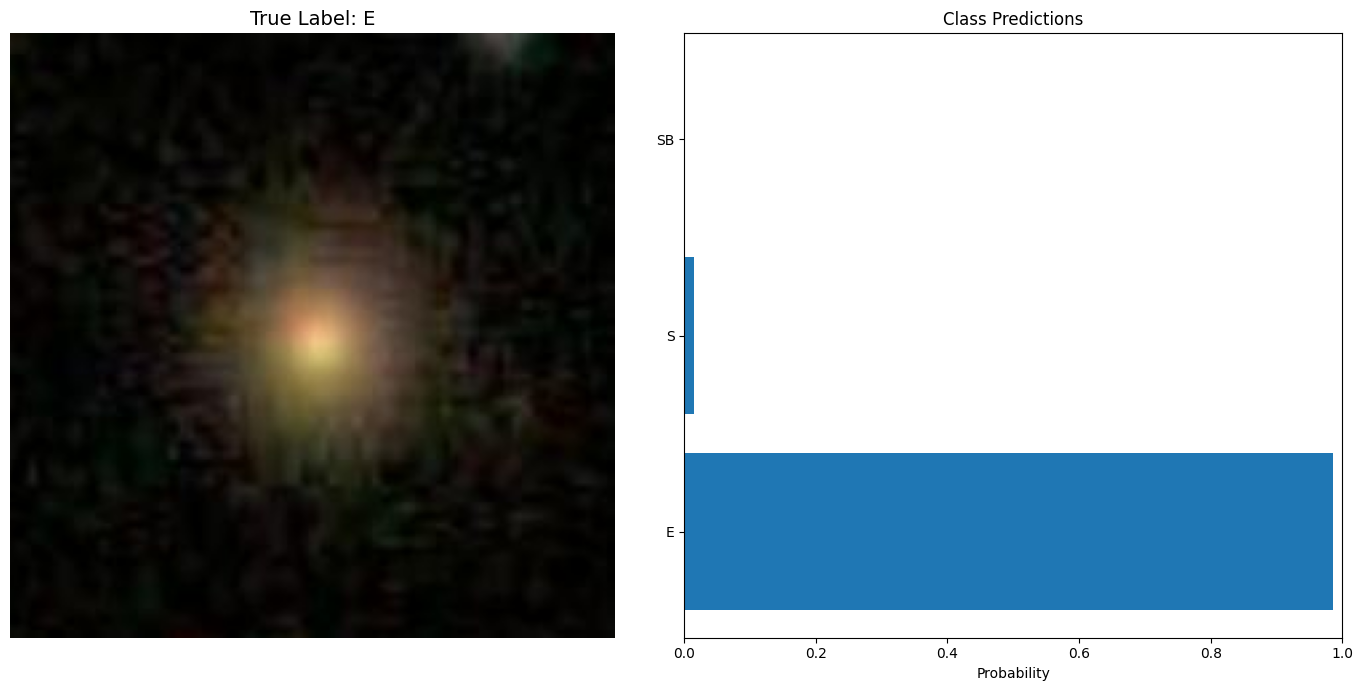

In [ ]:
# use an example image/images to test the model
test_image_path = '/content/dataset/images_E_S_SB_227x227_a_03_test/E/655.jpg'
true_label = extract_label_from_path(test_image_path) # should be 'E' in this case
print(true_label)

transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])
original_image, image_tensor = preprocess_image(test_image_path, transform)
probabilities = predict(model, image_tensor, device)

class_names = list(target_to_class.values())
# visualize the probabilities for each class(E, S, SB) to see how well model predicts
visualize_predictions(original_image, probabilities, class_names, true_label)

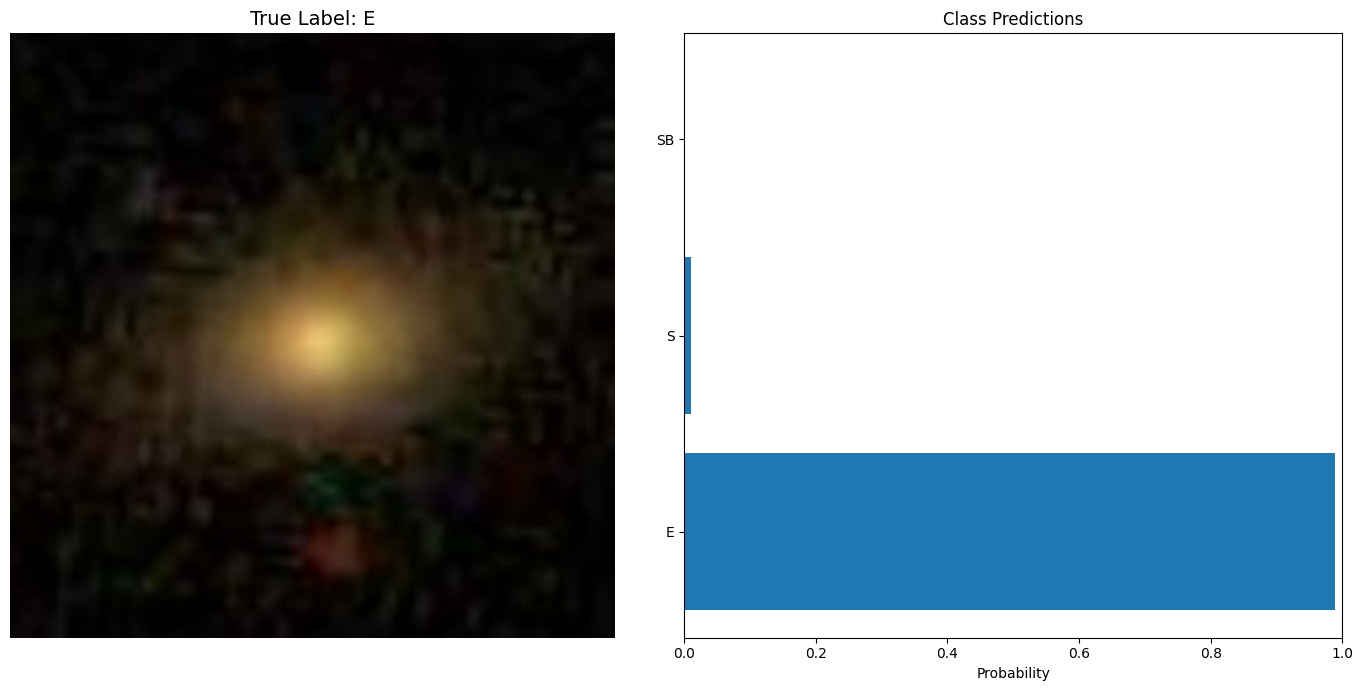

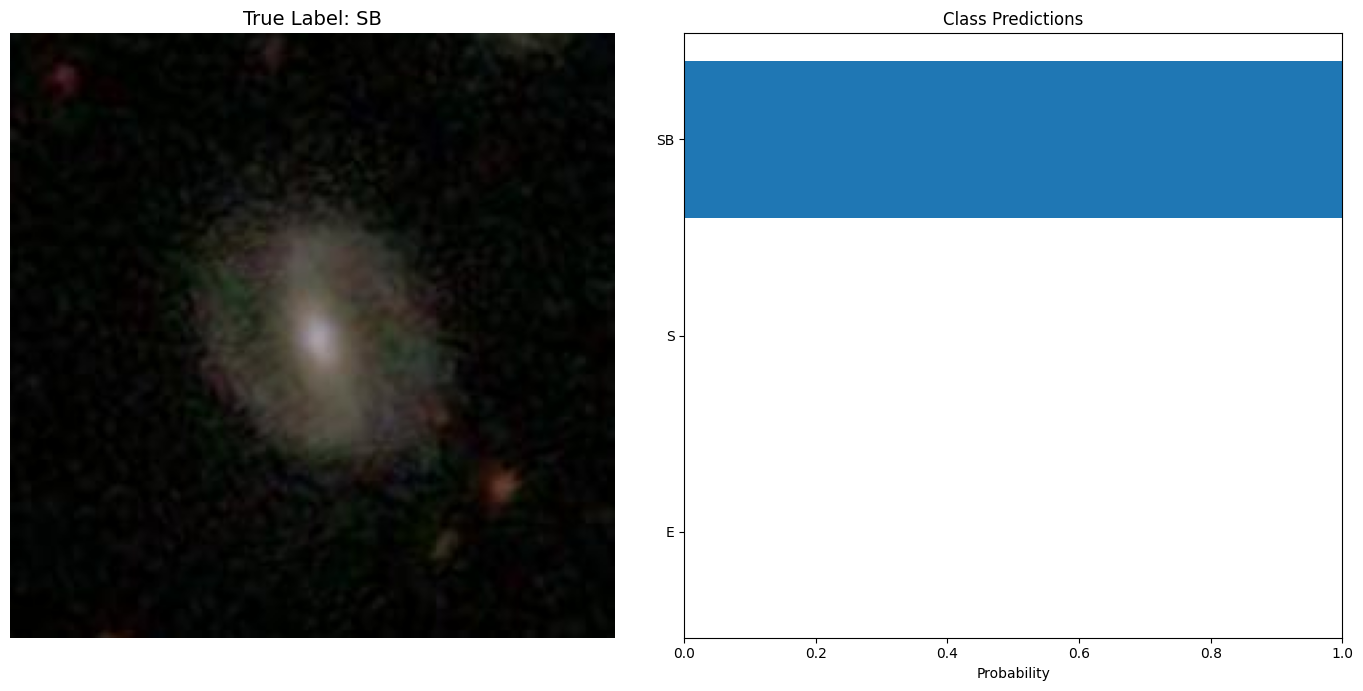

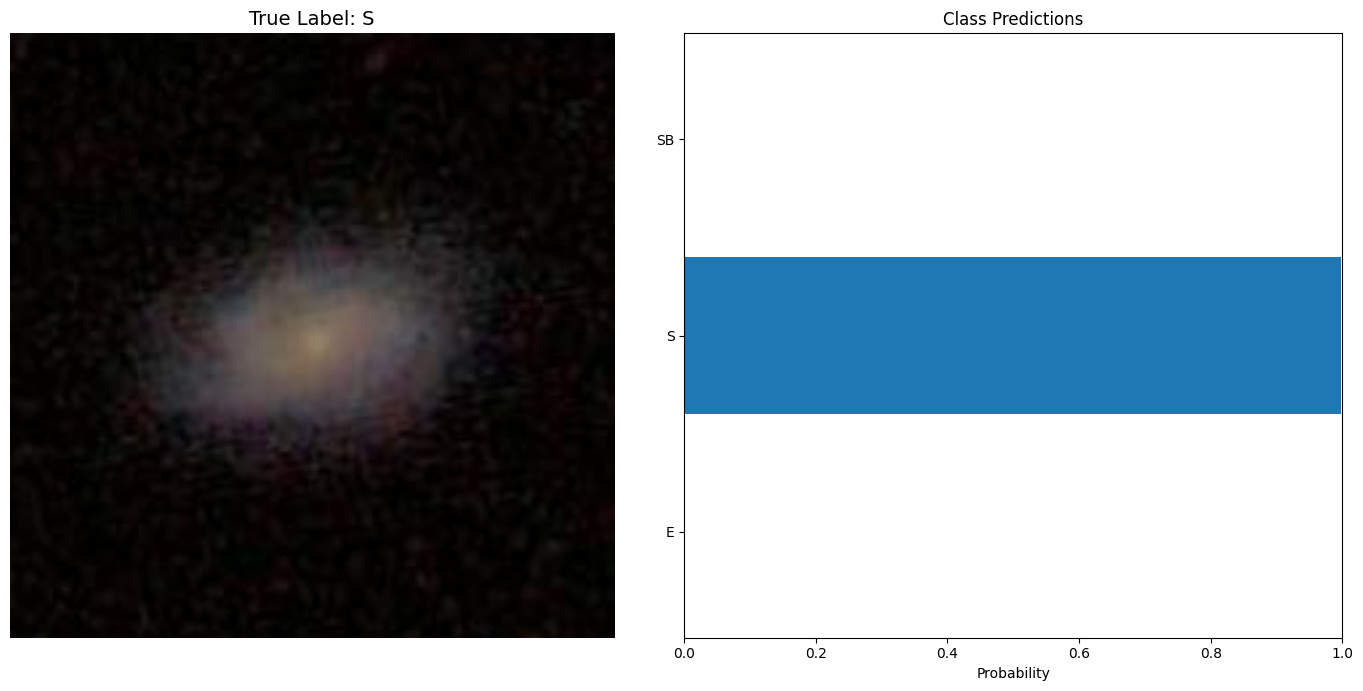

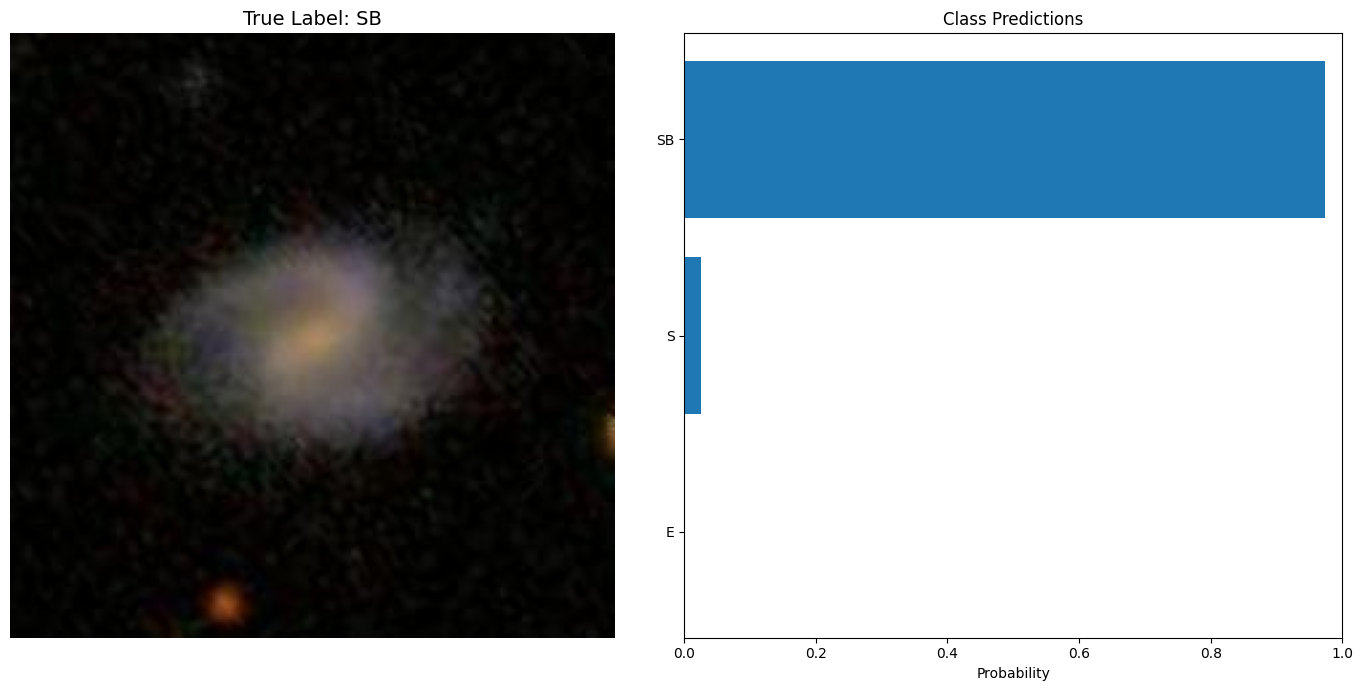

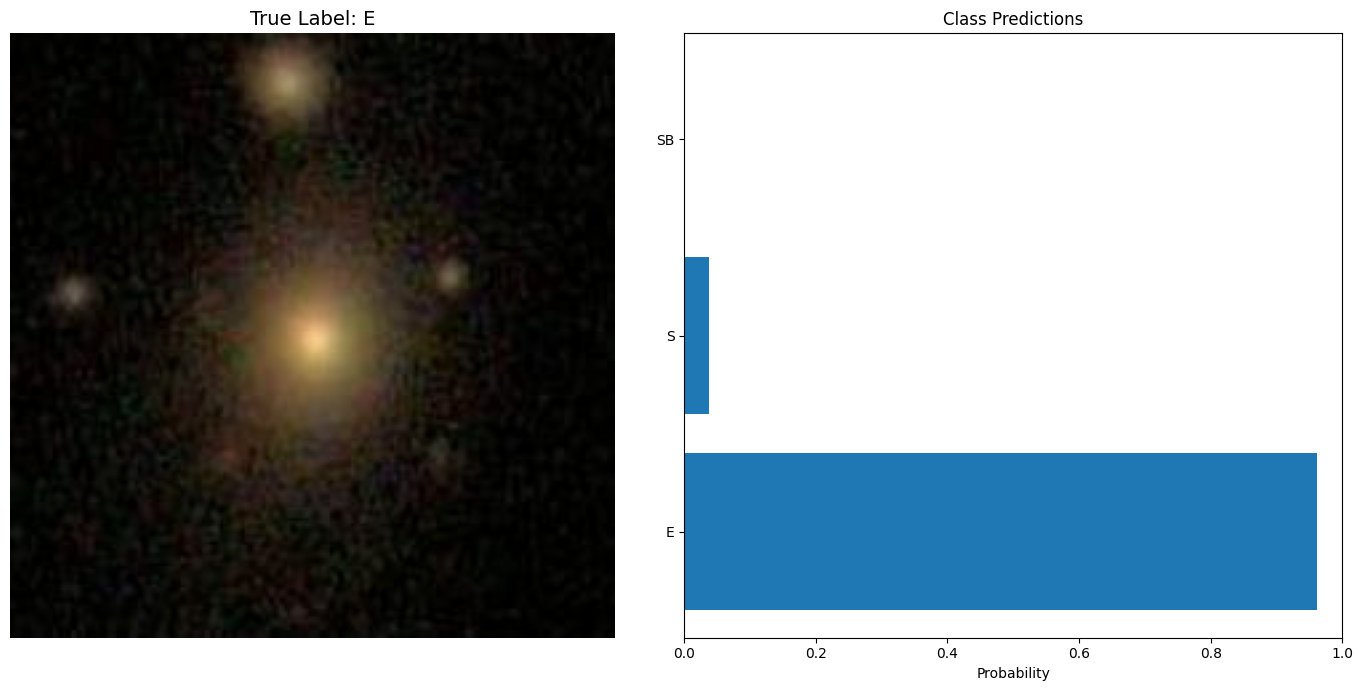

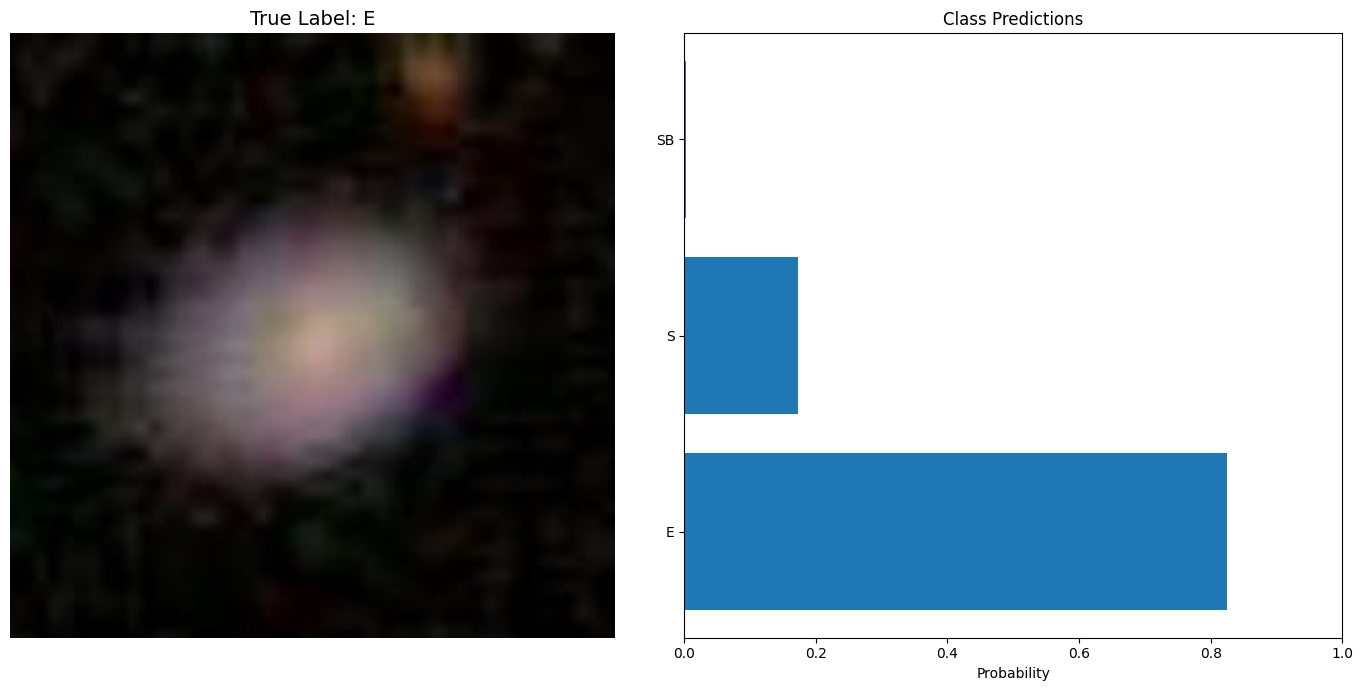

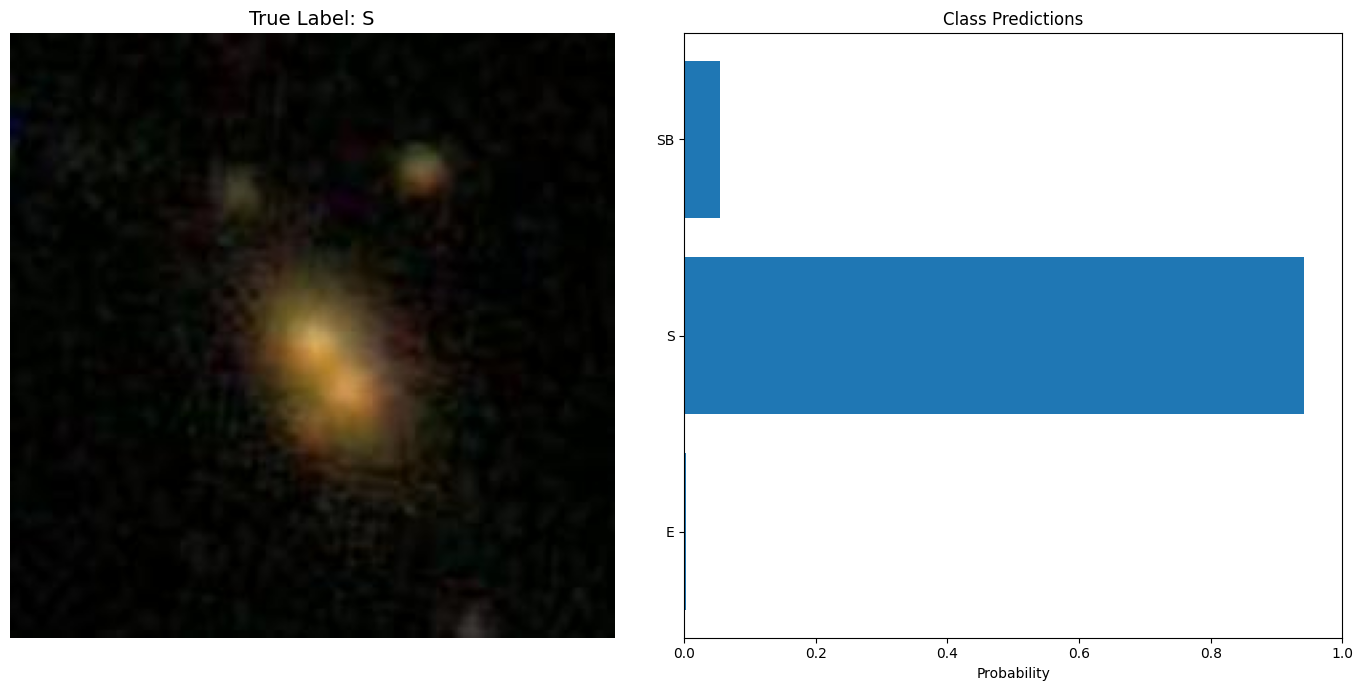

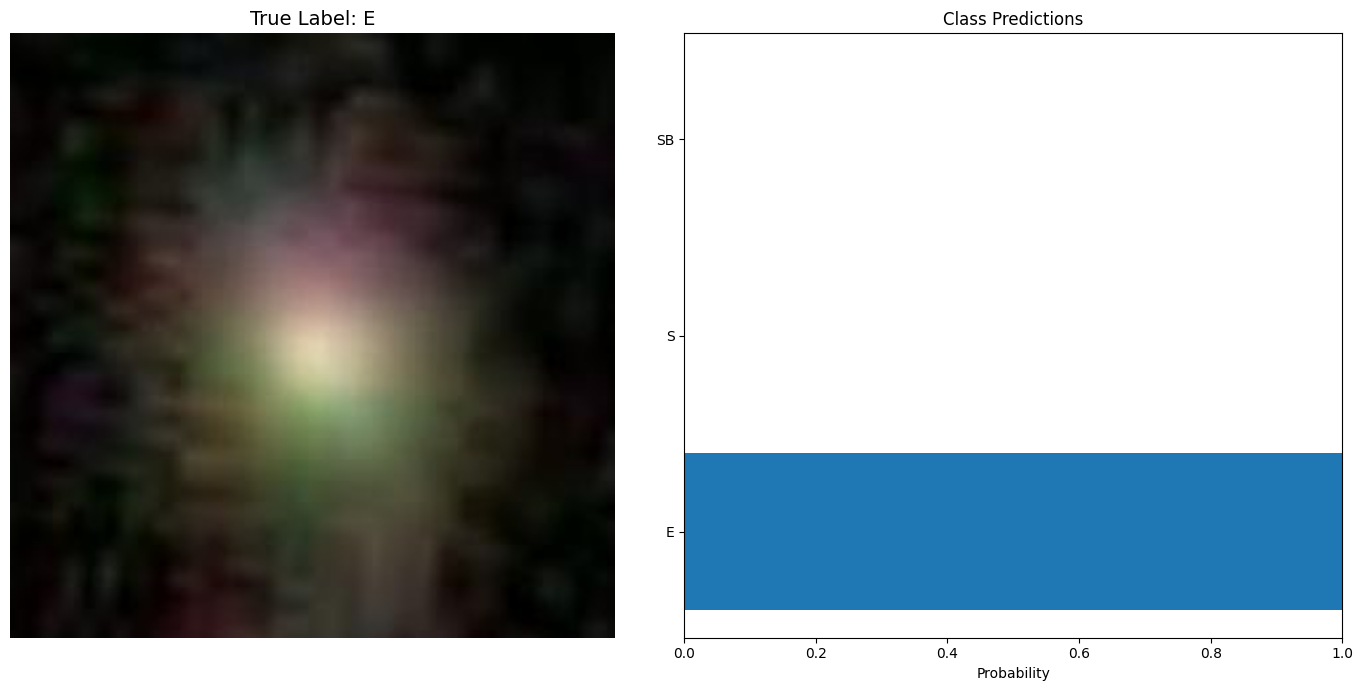

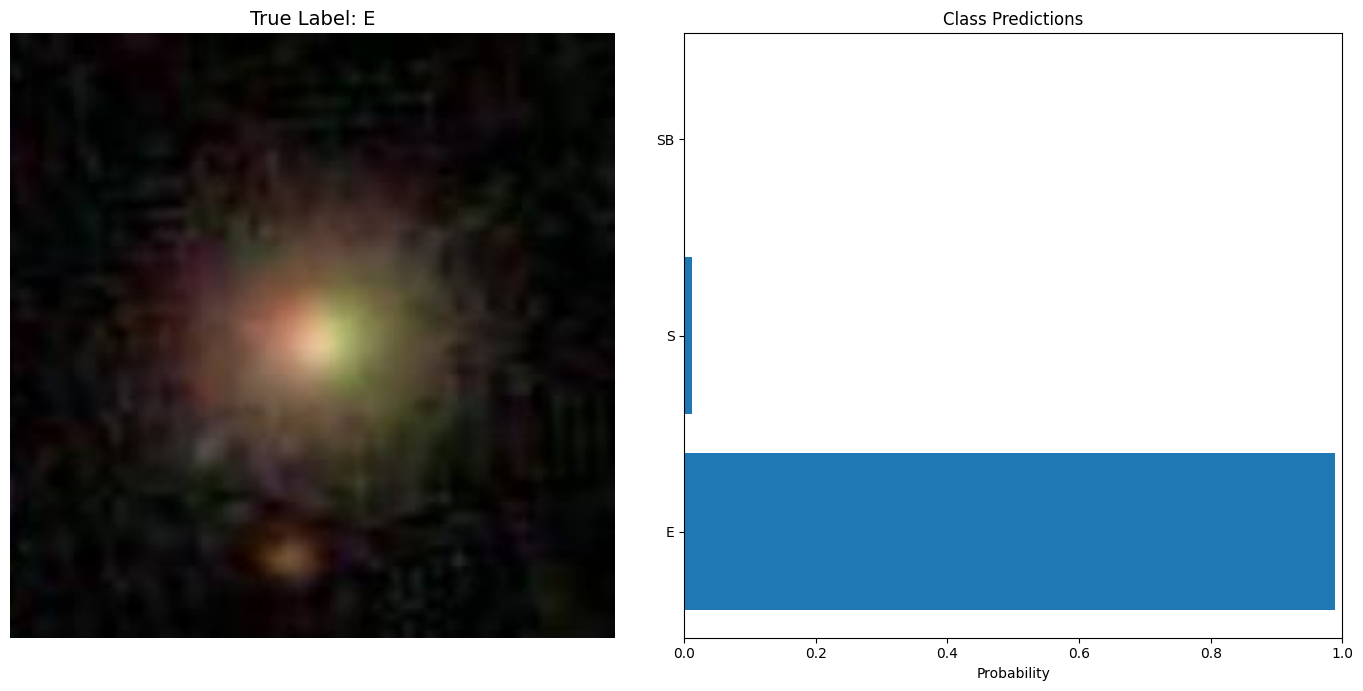

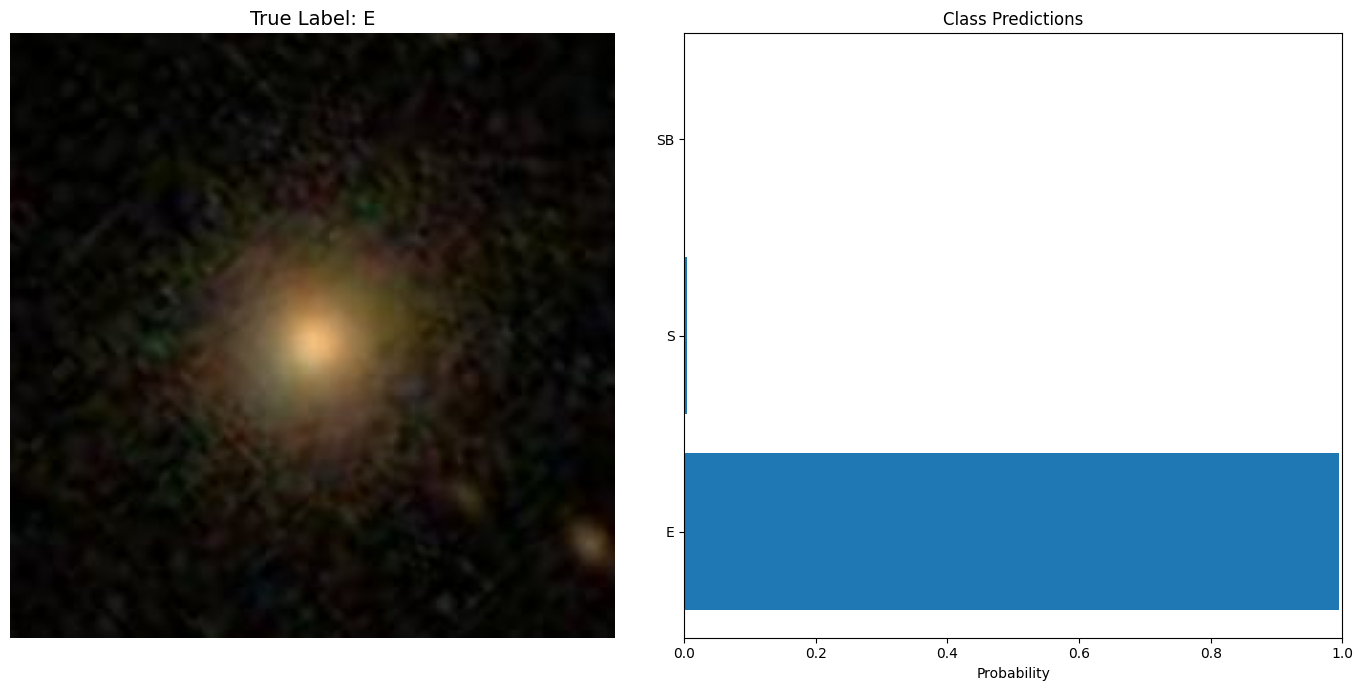

In [ ]:
# see how model performs on a set of 10 test images

# glob allows us to find files matching a specific pattern
from glob import glob
test_images = glob('/content/dataset/images_E_S_SB_227x227_a_03_test/*/*')
# select 10 random test images
test_example_images = np.random.choice(test_images, 10)
# apply our same functions for preprocessing, predicting(passing into model), and calc probabilities
for example in test_example_images:
  true_label = extract_label_from_path(example)
  original_image, image_tensor = preprocess_image(example, transform)
  probabilities = predict(model, image_tensor, device)
  class_names = list(target_to_class.values())
  # visualize the probabilities for each class(E, S, SB) to see how well model predicts
  visualize_predictions(original_image, probabilities, class_names, true_label)




In [ ]:
# finally, calculate the accuracy of the model on the test dataset
# look at predictions and compare it to true label
# will use sklearn.metrics accuracy_score
from sklearn.metrics import accuracy_score

all_predictions = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc = "Testing loop"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probabilities_tensor = torch.nn.functional.softmax(outputs, dim=1)
        # get the index of the label/class with the maximum probability for each image in the tensor
        predictions = torch.argmax(probabilities_tensor, dim = 1)
       # store predictions(predicted labels)
        all_predictions.extend(predictions.cpu().numpy())
       # store the true labels
        all_labels.extend(labels.cpu().numpy())

# function to compare predicted labels to true labels and return an accuracy
accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy: {accuracy:.2%}")







Testing loop:   0%|          | 0/419 [00:00<?, ?it/s]

Test Accuracy: 77.07%
